In [1]:
from heapq import merge
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

plt.style.use("ggplot")

2025-08-09 23:27:38.360508: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-09 23:27:38.362843: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-09 23:27:38.369533: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754792858.380671  117338 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754792858.383908  117338 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754792858.393072  117338 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Loss function

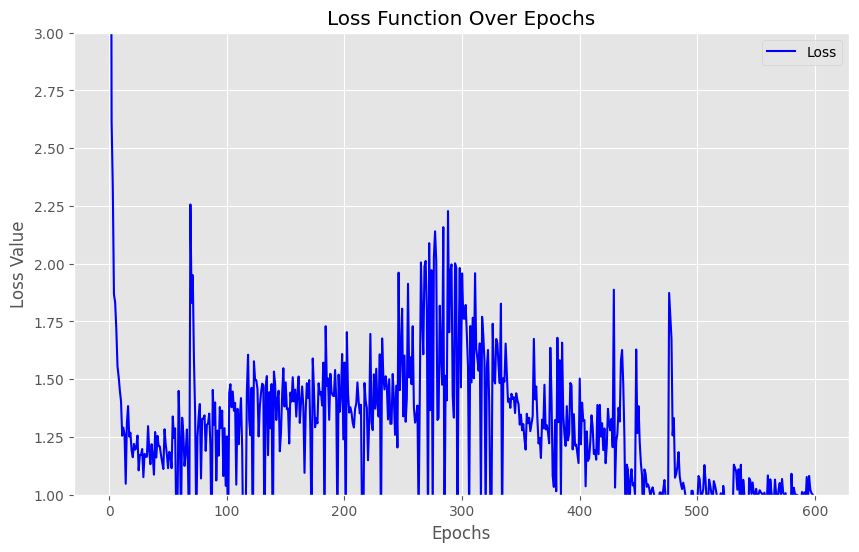

In [2]:
loss_csv = '../output/loss.csv'

with open(loss_csv, 'r') as f:
    lines = f.readlines()
    loss_values = [float(line.strip().split(',')[2]) for line in lines[1:]]

plt.figure(figsize=(10, 6))

plt.plot(loss_values, label='Loss', color='blue')
plt.title('Loss Function Over Epochs')
plt.ylim(1.0, 3.0)
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True)
plt.legend()


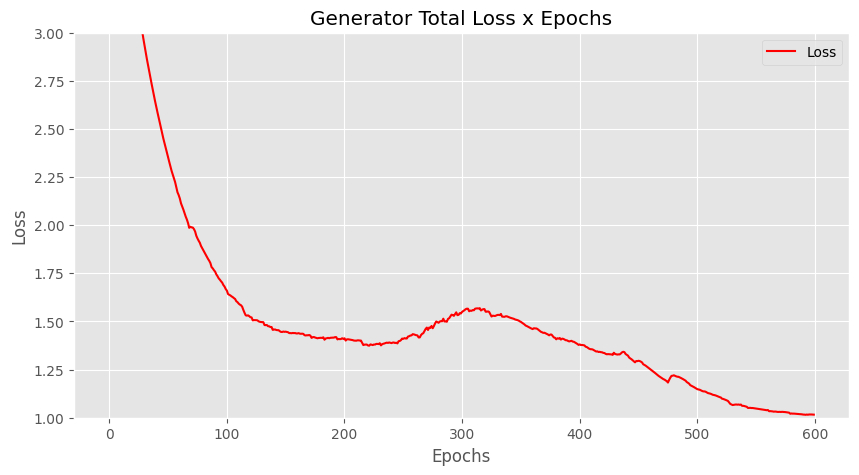

In [9]:
# ...existing code...
loss_csv = '../output/loss.csv'

with open(loss_csv, 'r') as f:
    lines = f.readlines()
    loss_values = [float(line.strip().split(',')[2]) for line in lines[1:]]

# Smoothing function (EMA)
def smooth_curve(values, weight=0.9):
    smoothed = []
    last = values[0]
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

smoothed_loss = smooth_curve(loss_values, weight=0.98)

plt.figure(figsize=(10, 5))
# plt.plot(loss_values, label='Loss', color='blue', alpha=0.3)
plt.plot(smoothed_loss, label='Loss', color='red')
plt.title('Generator Total Loss x Epochs')
plt.ylim(1.0, 3.0)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
# ...existing code...

## Wave Fields

In [4]:
def plot_vti_2d(file_path, title, output_path="output.png", n_labels=6):
    grid = pv.read(file_path)

    # plotter = pv.Plotter(border=True)
    plotter = pv.Plotter(border=True, window_size=[800, 800])

    # plotter.add_mesh(grid, cmap="viridis", show_scalar_bar=True)
    scalar_range = grid.get_data_range()
    clim = [scalar_range[0], scalar_range[1]]
    plotter.add_mesh(
        grid,
        cmap="viridis",
        show_scalar_bar=True,
        scalar_bar_args={
            'title': 'Scalar',
            'n_labels': n_labels,  # Discrete-like bar with few labels
            'vertical': True
        },
        clim=clim
    )

    plotter.add_title(title)

    plotter.view_xy()
    # plotter.camera.zoom(1.2)

    plotter.show()

def plot_vti_matplotlib(file_path, title, output_path="output.png", preview=False):

    grid = pv.read(file_path)

    dims = grid.dimensions
    spacing = grid.spacing
    origin = grid.origin

    scalars = grid.active_scalars.reshape(dims[1], dims[0])

    x = np.linspace(origin[0], origin[0] + spacing[0] * (dims[0] - 1), dims[0])
    z = np.linspace(origin[1], origin[1] + spacing[1] * (dims[1] - 1), dims[1])

    fig, ax = plt.subplots(figsize=(6, 6))

    contour = ax.contourf(x, z, scalars, cmap='viridis')

    cbar = fig.colorbar(contour, ax=ax)

    ax.set_aspect('equal')
    ax.invert_yaxis()

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Z (m)')
    ax.set_title(title)

    if not preview:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.tight_layout()
        plt.savefig(output_path, dpi=300)
        plt.close()

## Plotting Velocity Fields

In [5]:
plot_vti_matplotlib("../../acwv-solver/data/parallel.vti", "Parallel layers", output_path="../output/parallel.png")
plot_vti_matplotlib("../../acwv-solver/data/semicircle.vti", "Semicircle", output_path="../output/semicircle.png")
plot_vti_matplotlib("../../acwv-solver/data/layers.vti", "Bent layers", output_path="../output/bent.png")
plot_vti_matplotlib("../../acwv-solver/data/reservoir.vti", "Reservoir", output_path="../output/reservoir.png")